# 03 — Static Word Embeddings on Full-Concat Scrubbed+ Text

Word2Vec/fastText sentence-mean embeddings + Linear classifier.


In [1]:
import re
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec, FastText
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_recall_fscore_support, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)

RANDOM_STATE = 42
MIN_SAMPLES_PER_CLASS = 100
TEXT_COLUMN = 'text_full_concat_scrubbed_plus'
EMBEDDING_DIM = 200
OUTPUT_DIR = 'artifacts/origin_word2vec_fulltext_scrubbed_plus'
os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_STATE)


## Scrubbing vocabulary

In [2]:
# Scrubbing vocabulary: countries + region aliases + cultivars + producer context
# Lifted from 04.5 so that 02.1 / 03.1 / 04.1.1 / 06.1 / 07.1 are a fair comparison.
COUNTRY_TERMS = {
    "Ethiopia": ["ethiopia", "ethiopian"],
    "Colombia": ["colombia", "colombian", "columbian"],
    "Panama": ["panama", "panamanian"],
    "Kenya": ["kenya", "kenyan"],
    "Indonesia": ["indonesia", "indonesian"],
    "Guatemala": ["guatemala", "guatemalan"],
    "Costa Rica": ["costa rica", "costa rican", "costarican"],
    "El Salvador": ["el salvador", "salvadoran", "salvadorean", "salvadorian"],
    "Rwanda": ["rwanda", "rwandan"],
    "Brazil": ["brazil", "brazilian"],
    "Honduras": ["honduras", "honduran"],
    "Peru": ["peru", "peruvian"],
    "Taiwan": ["taiwan", "taiwanese"],
    "Papua New Guinea": ["papua new guinea", "papua new guinean"],
    "Nicaragua": ["nicaragua", "nicaraguan"],
    "Burundi": ["burundi", "burundian"],
    "Thailand": ["thailand", "thai"],
    "India": ["india", "indian"],
    "Mexico": ["mexico", "mexican"],
    "Tanzania": ["tanzania", "tanzanian"],
    "Yemen": ["yemen", "yemeni"],
    "Ecuador": ["ecuador", "ecuadorian"],
    "Bolivia": ["bolivia", "bolivian"],
    "Jamaica": ["jamaica", "jamaican"],
    "Uganda": ["uganda", "ugandan"],
    "Dominican Republic": ["dominican republic", "dominican"],
    "Zambia": ["zambia", "zambian"],
    "China": ["china", "chinese"],
    "Vietnam": ["vietnam", "vietnamese"],
    "Philippines": ["philippines", "philippine", "filipino"],
    "Malaysia": ["malaysia", "malaysian"],
    "Laos": ["laos", "laotian"],
    "Zimbabwe": ["zimbabwe", "zimbabwean"],
    "Haiti": ["haiti", "haitian"],
    "Puerto Rico": ["puerto rico", "puerto rican", "puertorican"],
    "Nepal": ["nepal", "nepalese", "nepali"],
    "Myanmar": ["myanmar", "burmese"],
    "Cameroon": ["cameroon", "cameroonian"],
    "Australia": ["australia", "australian"],
    "South Africa": ["south africa", "south african"],
    "Malawi": ["malawi", "malawian"],
    "Venezuela": ["venezuela", "venezuelan", "merida state", "mocoties valley"],
    "Timor-Leste": ["east timor", "timor leste", "timorese"],
    "DR Congo": ["democratic republic of the congo", "dr congo", "congo", "congolese"],
    "United Kingdom": ["united kingdom", "british", "pitcairn island", "saint helena", "st helena", "sandy bay valley"],
    "United States": [
        "usa", "united states", "american",
        "hawaii", "hawai'i", "hawaiian", "hawaii island",
        "big island", "kona", "puna district", "holualoa", "oahu", "maui", "kauai",
        "ka u", "ka'u", "kau",
    ],
}

REGION_ALIASES = {
    "Ethiopia": ["yirgacheffe", "sidamo", "sidama", "guji", "gedeb", "gedeo", "kochere", "hambela",
                 "shakiso", "jimma", "limu", "oromia", "harrar", "kaffa", "bench maji", "bench-maji",
                 "arbegona", "bensa"],
    "Colombia": ["huila", "cauca", "narino", "tolima", "quindio", "caldas", "risaralda", "antioquia",
                 "cundinamarca", "santander", "pitalito", "acevedo", "planadas", "gaitania", "piendamo",
                 "caicedonia", "san agustin", "armenia"],
    "Panama": ["boquete", "chiriqui", "volcan", "jaramillo", "alto quiel", "paso ancho",
               "piedra candela", "canas verdes", "silla del pando", "renacimiento"],
    "Kenya": ["nyeri", "kirinyaga", "kiambu", "embu", "muranga", "murang'a", "thika", "ruiru",
              "mathira", "meru", "nakuru", "gichugu", "karatina"],
    "Indonesia": ["sumatra", "aceh", "gayo", "lintong", "mandheling", "sidikalang", "toraja",
                  "sulawesi", "java", "bali", "kintamani", "flores", "kerinci"],
    "Guatemala": ["huehuetenango", "antigua", "acatenango", "fraijanes", "coban", "atitlan",
                  "chimaltenango", "quiche", "solola", "palencia", "sacatepequez", "san marcos",
                  "hoja blanca", "cuilco"],
    "Costa Rica": ["tarrazu", "central valley", "west valley", "tres rios", "naranjo", "dota",
                   "poas", "alajuela", "brunca", "turrialba", "coto brus", "chirripo"],
    "El Salvador": ["ahuachapan", "chalatenango", "apaneca", "ilamatepec", "santa ana",
                    "el boqueron", "quetzaltepec", "juayua", "ataco"],
    "Rwanda": ["gakenke", "nyamasheke", "karongi", "huye", "nyamagabe", "rulindo", "gikongoro",
               "lake kivu"],
    "Brazil": ["cerrado", "mogiana", "minas gerais", "mantiqueira", "sul de minas",
               "chapada diamantina", "carmo de minas"],
    "Honduras": ["marcala", "copan", "ocotepeque", "comayagua", "intibuca", "santa barbara",
                 "el paraiso", "capucas"],
    "Peru": ["cajamarca", "jaen", "san ignacio", "chanchamayo", "cusco", "villa rica", "oxapampa",
             "junin", "puno"],
    "Taiwan": ["alishan", "yunlin", "chiayi", "chia yi", "nantou", "taichung", "pingtung"],
    "Papua New Guinea": ["wahgi valley", "western highlands", "eastern highlands", "jiwaka",
                         "kainantu", "okapa"],
    "Nicaragua": ["jinotega", "matagalpa", "nueva segovia", "madriz", "ocotal", "dipilto"],
    "Burundi": ["kayanza", "ngozi", "muramvya", "muyinga", "bururi"],
    "Thailand": ["chiang rai", "doi chang", "doi pangkhon", "chiang mai", "nan province"],
    "India": ["coorg", "chikmagalur", "karnataka", "bababudangiri", "nilgiris"],
    "Mexico": ["chiapas", "oaxaca", "veracruz", "coatepec", "pluma hidalgo"],
    "Tanzania": ["mbeya", "ruvuma", "ngorongoro", "arusha", "kilimanjaro", "mbozi"],
    "Yemen": ["haraaz", "haraz", "sanaa", "bani matar", "hayma"],
    "Ecuador": ["loja", "pichincha", "imbabura", "zamora", "chimborazo", "saraguro"],
    "Bolivia": ["caranavi", "yungas", "la paz"],
    "Jamaica": ["blue mountain", "blue mountains"],
    "Uganda": ["rwenzori", "bugisu", "sipi falls"],
    "Vietnam": ["lam dong", "quang tri", "dalat", "cau dat"],
    "Philippines": ["benguet", "bukidnon", "davao"],
    "China": ["yunnan", "baoshan", "puer", "pu'er", "lincong"],
    "Puerto Rico": ["utuado", "yauco", "adjuntas"],
    "Venezuela": ["mocoties valley", "merida state"],
    "Malawi": ["malawi"],
}

REGION_ONLY_TERMS = [
    "central america", "south america", "latin america",
    "east africa", "central africa", "west africa", "africa",
    "asia", "the americas", "americas",
    "central and south america", "south and central america",
    "east and central africa", "various africa growing regions",
]

CULTIVAR_TERMS = [
    "sl28", "sl-28", "sl 28", "sl34", "sl-34", "sl 34",
    "ruiru 11", "ruiru-11", "batian", "k7",
    "gesha", "geisha",
    "pacamara", "pache", "villa sarchi",
    "bourbon", "pink bourbon", "yellow bourbon", "red bourbon",
    "caturra", "catuai", "catuai vermelho", "catuai amarelo",
    "typica", "mundo novo",
    "maragogipe", "maragogype", "maracaturra",
    "castillo", "colombia variety", "variedad colombia", "tabi",
    "heirloom", "ethiopian heirloom",
    "tim tim", "s795", "ateng",
    "catimor", "sarchimor", "icatu", "obata",
]

PRODUCER_CONTEXT_TERMS = [
    "finca", "hacienda", "beneficio",
    "cup of excellence",
    "washing station", "wet mill",
    "best of panama",
]

all_scrub_terms = []
for v in COUNTRY_TERMS.values():    all_scrub_terms.extend(v)
for v in REGION_ALIASES.values():   all_scrub_terms.extend(v)
all_scrub_terms.extend(REGION_ONLY_TERMS)
all_scrub_terms.extend(CULTIVAR_TERMS)
all_scrub_terms.extend(PRODUCER_CONTEXT_TERMS)
all_scrub_terms = sorted(set(all_scrub_terms), key=len, reverse=True)
print(f'Loaded {len(all_scrub_terms)} scrub terms')

SCRUB_PATTERN = re.compile(
    r'\b(' + '|'.join(re.escape(t) for t in all_scrub_terms) + r')\b',
    flags=re.IGNORECASE,
)

def scrub(text):
    if not isinstance(text, str) or not text:
        return ''
    return SCRUB_PATTERN.sub(' [ORIGIN] ', text)


Loaded 403 scrub terms


## Build text column

In [3]:
# Concat Blind Assessment + Notes + Who Should Drink It + Bottom Line, then scrub
def minimal_raw_text(text):
    text = '' if pd.isna(text) else str(text)
    return re.sub(r'\s+', ' ', text).strip().lower()

def normalize_text_keep_brackets(text):
    text = minimal_raw_text(text)
    text = re.sub(r'[^a-z0-9\s\[\]]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

EXTRA_TEXT_COLS = ['Blind Assessment', 'Notes', 'Who Should Drink It', 'Bottom Line']

def concat_and_scrub(row):
    pieces = []
    for col in EXTRA_TEXT_COLS:
        v = row[col]
        if pd.notna(v) and str(v).strip():
            raw = minimal_raw_text(v)
            scrubbed = scrub(raw)
            cleaned = normalize_text_keep_brackets(scrubbed)
            pieces.append(cleaned)
    return ' '.join(p for p in pieces if p)

df = pd.read_csv('Data/final_coffee_reviews.csv')
df['text_full_concat_scrubbed_plus'] = df.apply(concat_and_scrub, axis=1)
df['text_raw_minimal'] = df['Blind Assessment'].fillna('').map(minimal_raw_text)
df['origin_country'] = df['Country'].astype('string').str.strip().replace('', pd.NA)

work = df[(df['text_raw_minimal'].str.len() >= 30) & (df['origin_country'].notna())].copy()
counts = work['origin_country'].value_counts()
valid_classes = counts[counts >= MIN_SAMPLES_PER_CLASS].index
work = work[work['origin_country'].isin(valid_classes)].copy().reset_index(drop=True)

# Leakage audit
def contains_own_country(row):
    t = row['text_full_concat_scrubbed_plus'].lower()
    c = str(row['origin_country']).lower()
    return c in t if c and t else False
work['leaks_country'] = work.apply(contains_own_country, axis=1)
leak_rate = float(work['leaks_country'].mean())

print(f'Rows: {len(work)} | Classes: {work["origin_country"].nunique()}')
print(f'Avg scrubbed+ text length (chars): {int(work["text_full_concat_scrubbed_plus"].str.len().mean())}')
print(f'Country-name leakage: {leak_rate:.1%}  (target: <2%)')


Rows: 6820 | Classes: 15
Avg scrubbed+ text length (chars): 875
Country-name leakage: 0.8%  (target: <2%)


## 70/15/15 stratified split

In [4]:
# Same 70/15/15 stratified split as the rest of the pipeline
y = work['origin_country']
row_idx = work.index
train_idx, temp_idx, y_train, y_temp = train_test_split(
    row_idx, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)
print('Train/Val/Test:', len(train_idx), len(val_idx), len(test_idx))


Train/Val/Test: 4774 1023 1023


## Train Word2Vec + fastText on the TRAIN split only, then mean-pool

In [5]:
def tokenize(text):
    return text.split() if text else []

train_tokens = work.loc[train_idx, TEXT_COLUMN].fillna('').map(tokenize).tolist()
val_tokens   = work.loc[val_idx,   TEXT_COLUMN].fillna('').map(tokenize).tolist()
test_tokens  = work.loc[test_idx,  TEXT_COLUMN].fillna('').map(tokenize).tolist()

print('Training Word2Vec on train split ...')
w2v = Word2Vec(
    sentences=train_tokens, vector_size=EMBEDDING_DIM, window=5, min_count=2,
    sg=0, workers=4, epochs=10, seed=RANDOM_STATE,
)
print('Training fastText on train split ...')
ft = FastText(
    sentences=train_tokens, vector_size=EMBEDDING_DIM, window=5, min_count=2,
    sg=0, workers=4, epochs=10, seed=RANDOM_STATE,
)

def mean_embed(tokens, kv, dim):
    vecs = [kv[t] for t in tokens if t in kv.key_to_index]
    if not vecs:
        return np.zeros(dim, dtype=np.float32)
    return np.mean(vecs, axis=0)

def build_matrix(token_lists, kv, dim):
    return np.vstack([mean_embed(toks, kv, dim) for toks in token_lists])

X_train_w2v = build_matrix(train_tokens, w2v.wv, EMBEDDING_DIM)
X_val_w2v   = build_matrix(val_tokens,   w2v.wv, EMBEDDING_DIM)
X_test_w2v  = build_matrix(test_tokens,  w2v.wv, EMBEDDING_DIM)

X_train_ft = build_matrix(train_tokens, ft.wv, EMBEDDING_DIM)
X_val_ft   = build_matrix(val_tokens,   ft.wv, EMBEDDING_DIM)
X_test_ft  = build_matrix(test_tokens,  ft.wv, EMBEDDING_DIM)

print('Feature matrix shapes:', X_train_w2v.shape, X_train_ft.shape)


Training Word2Vec on train split ...
Training fastText on train split ...
Feature matrix shapes: (4774, 200) (4774, 200)


## Small grid: {Word2Vec, fastText} × {Linear SVM, Logistic Regression}

In [6]:
def evaluate(name, model, X_val_, X_test_):
    y_val_pred  = model.predict(X_val_)
    y_test_pred = model.predict(X_test_)
    val_p, val_r, val_f1, _   = precision_recall_fscore_support(y_val,  y_val_pred,  average='macro', zero_division=0)
    test_p, test_r, test_f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average='macro', zero_division=0)
    return {
        'model': name,
        'val_accuracy':          accuracy_score(y_val,  y_val_pred),
        'val_balanced_accuracy': balanced_accuracy_score(y_val,  y_val_pred),
        'val_f1_macro':          val_f1,
        'test_accuracy':          accuracy_score(y_test, y_test_pred),
        'test_balanced_accuracy': balanced_accuracy_score(y_test, y_test_pred),
        'test_f1_macro':          test_f1,
        'y_test_pred': y_test_pred,
    }

specs = [
    ('Word2Vec + Linear SVM (C=1)',          LinearSVC(C=1.0, class_weight='balanced', dual='auto', max_iter=10000, random_state=RANDOM_STATE), X_train_w2v, X_val_w2v, X_test_w2v),
    ('Word2Vec + LogReg (C=1)',              LogisticRegression(C=1.0, max_iter=5000, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE), X_train_w2v, X_val_w2v, X_test_w2v),
    ('fastText + Linear SVM (C=1)',          LinearSVC(C=1.0, class_weight='balanced', dual='auto', max_iter=10000, random_state=RANDOM_STATE), X_train_ft, X_val_ft, X_test_ft),
    ('fastText + LogReg (C=1)',              LogisticRegression(C=1.0, max_iter=5000, solver='liblinear', class_weight='balanced', random_state=RANDOM_STATE), X_train_ft, X_val_ft, X_test_ft),
]

results = []
best_score = -1
best_name = None
best_pred = None
for name, clf, Xtr, Xv, Xte in specs:
    clf.fit(Xtr, y_train)
    r = evaluate(name, clf, Xv, Xte)
    print(f"{name:40s} val F1={r['val_f1_macro']:.4f}  test F1={r['test_f1_macro']:.4f}")
    if r['val_f1_macro'] > best_score:
        best_score = r['val_f1_macro']
        best_name = name
        best_pred = r['y_test_pred']
    r.pop('y_test_pred')
    results.append(r)

results_df = pd.DataFrame(results).sort_values('val_f1_macro', ascending=False).reset_index(drop=True)
print()
print('Best (by val F1):', best_name)
results_df


Word2Vec + Linear SVM (C=1)              val F1=0.3580  test F1=0.3603
Word2Vec + LogReg (C=1)                  val F1=0.3561  test F1=0.3668
fastText + Linear SVM (C=1)              val F1=0.3682  test F1=0.3595
fastText + LogReg (C=1)                  val F1=0.3599  test F1=0.3536

Best (by val F1): fastText + Linear SVM (C=1)


,model,val_accuracy,val_balanced_accuracy,val_f1_macro,test_accuracy,test_balanced_accuracy,test_f1_macro
0,fastText + Linear SVM (C=1),0.496579,0.394799,0.368151,0.495601,0.390389,0.359540
1,fastText + LogReg (C=1),0.483871,0.376599,0.359851,0.477028,0.375209,0.353561
2,Word2Vec + Linear SVM (C=1),0.502444,0.391765,0.358045,0.504399,0.386860,0.360337
3,Word2Vec + LogReg (C=1),0.494624,0.375245,0.356119,0.502444,0.389220,0.366786


## Per-class report and confusion matrix for the winning model

Winner: fastText + Linear SVM (C=1)
  test Macro-F1: 0.3595
  test Balanced Acc: 0.3904
  test Accuracy: 0.4956

               precision    recall  f1-score   support

     Ethiopia      0.798     0.676     0.732       299
     Colombia      0.580     0.318     0.410       148
        Kenya      0.713     0.733     0.723       105
    Guatemala      0.410     0.190     0.260        84
    Indonesia      0.500     0.574     0.534        68
   Costa Rica      0.318     0.250     0.280        56
       Panama      0.530     0.660     0.588        53
United States      0.451     0.711     0.552        45
  El Salvador      0.238     0.278     0.256        36
       Brazil      0.255     0.400     0.312        30
       Rwanda      0.293     0.444     0.353        27
         Peru      0.054     0.100     0.070        20
    Nicaragua      0.111     0.211     0.145        19
     Honduras      0.053     0.111     0.071        18
       Mexico      0.071     0.200     0.105        15

     

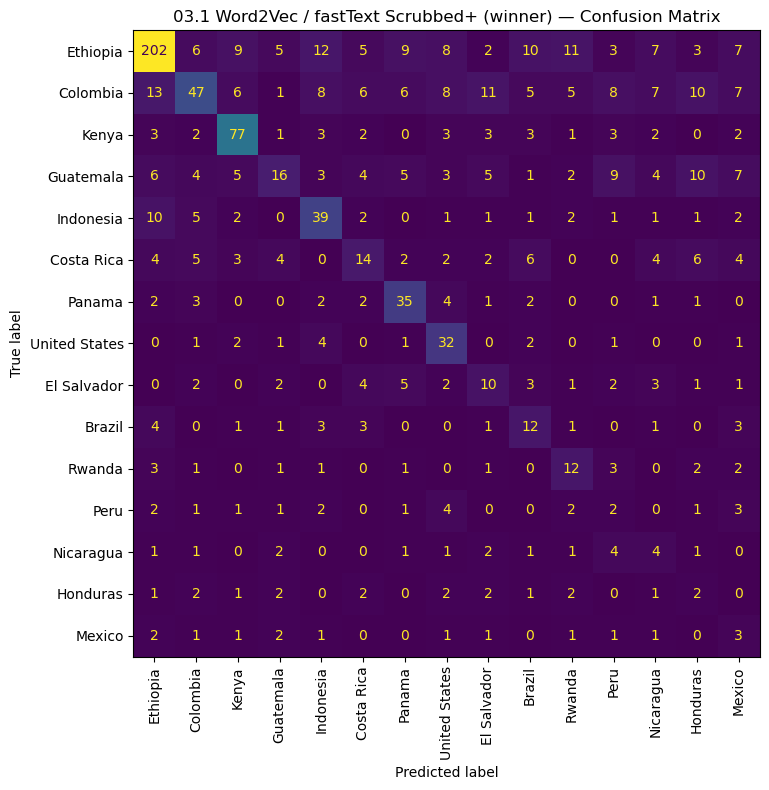

In [7]:
class_order = work['origin_country'].value_counts().index.tolist()
print(f'Winner: {best_name}')
print(f'  test Macro-F1: {f1_score(y_test, best_pred, average="macro", zero_division=0):.4f}')
print(f'  test Balanced Acc: {balanced_accuracy_score(y_test, best_pred):.4f}')
print(f'  test Accuracy: {accuracy_score(y_test, best_pred):.4f}')
print()
print(classification_report(y_test, best_pred, labels=class_order, zero_division=0, digits=3))

cm = confusion_matrix(y_test, best_pred, labels=class_order)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order).plot(
    ax=ax, xticks_rotation=90, colorbar=False,
)
plt.title('03.1 Word2Vec / fastText Scrubbed+ (winner) — Confusion Matrix')
plt.tight_layout()
plt.show()


## Save results

In [8]:
with open(os.path.join(OUTPUT_DIR, 'results.json'), 'w') as f:
    json.dump({
        'notebook': '03.1_Word2Vec_FullText_Scrubbed_Plus',
        'text_column': TEXT_COLUMN,
        'text_columns_used': EXTRA_TEXT_COLS,
        'scrub_tiers': ['countries_and_adjectivals', 'coffee_region_aliases', 'cultivars', 'producer_context_terms'],
        'num_scrub_terms': len(all_scrub_terms),
        'post_scrub_leakage_rate': leak_rate,
        'embedding_dim': EMBEDDING_DIM,
        'winner': best_name,
        'all_models': results,
    }, f, indent=2, default=float)
print('Saved', os.path.join(OUTPUT_DIR, 'results.json'))


Saved artifacts/origin_word2vec_fulltext_scrubbed_plus\results.json
